In [1]:
from pathlib import Path
import sys
import os

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mediapipe as mp

from ultralytics import YOLO

from scipy.signal import find_peaks

from IPython.display import Video, display

print("Python :", sys.executable)
print("MediaPipe :", mp.__version__)

Python : C:\Users\USER\.conda\envs\footy\python.exe
MediaPipe : 0.10.35


In [2]:
VIDEO_PATH = Path(
    r"C:\Users\USER\Downloads\BMX_FreeF_diehm_run1.mp4"
)

OUTPUT_DIR = (
    VIDEO_PATH.parent /
    f"{VIDEO_PATH.stem}_analysis"
)

OUTPUT_DIR.mkdir(exist_ok=True)

print("Vidéo :", VIDEO_PATH)
print("Dossier de sortie :", OUTPUT_DIR)

if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"Vidéo introuvable : {VIDEO_PATH}"
    )


Vidéo : C:\Users\USER\Downloads\BMX_FreeF_diehm_run1.mp4
Dossier de sortie : C:\Users\USER\Downloads\BMX_FreeF_diehm_run1_analysis


In [3]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

FPS = cap.get(cv2.CAP_PROP_FPS)
FRAME_COUNT = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

DURATION = FRAME_COUNT / FPS

cap.release()

print(f"Résolution : {WIDTH} × {HEIGHT}")
print(f"FPS        : {FPS:.2f}")
print(f"Frames     : {FRAME_COUNT}")
print(f"Durée      : {DURATION:.2f} s")

Résolution : 1920 × 1080
FPS        : 25.00
Frames     : 1552
Durée      : 62.08 s


In [4]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

MODEL_DIR = (
    Path(r"C:\Users\USER\Downloads")
    / "mediapipe_models"
)

MODEL_DIR.mkdir(exist_ok=True)

POSE_MODEL = MODEL_DIR / "pose_landmarker_heavy.task"

POSE_URL = (
    "https://storage.googleapis.com/"
    "mediapipe-models/pose_landmarker/"
    "pose_landmarker_heavy/float16/1/"
    "pose_landmarker_heavy.task"
)

if not POSE_MODEL.exists():

    print("Téléchargement du modèle Pose Landmarker...")

    urllib.request.urlretrieve(
        POSE_URL,
        POSE_MODEL
    )

    print("Téléchargement terminé.")

else:

    print("Modèle déjà présent.")

print(POSE_MODEL)
print(
    f"Taille : "
    f"{POSE_MODEL.stat().st_size / 1024 / 1024:.1f} MB"
)


Modèle déjà présent.
C:\Users\USER\Downloads\mediapipe_models\pose_landmarker_heavy.task
Taille : 29.2 MB


In [5]:
base_options = python.BaseOptions(
    model_asset_path=str(POSE_MODEL)
)

pose_options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,

    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

pose_landmarker = (
    vision.PoseLandmarker
    .create_from_options(pose_options)
)

print("Pose Landmarker : OK")


Pose Landmarker : OK


In [6]:
yolo_model = YOLO("yolo26n.pt")

print("YOLO chargé.")

YOLO chargé.


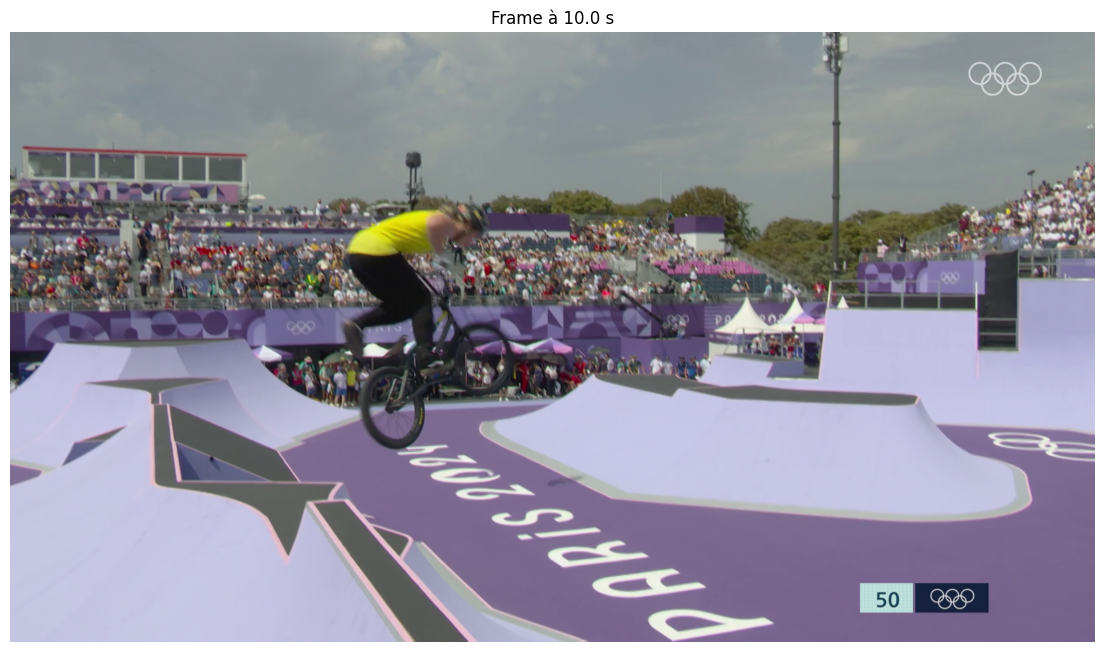

In [7]:
TEST_TIME = 10.0

cap = cv2.VideoCapture(str(VIDEO_PATH))

cap.set(
    cv2.CAP_PROP_POS_MSEC,
    TEST_TIME * 1000
)

ret, frame = cap.read()

cap.release()

if not ret:
    raise RuntimeError(
        "Impossible de récupérer la frame."
    )

frame_rgb = cv2.cvtColor(
    frame,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 8))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title(f"Frame à {TEST_TIME:.1f} s")
plt.show()


In [8]:
# mp_image = mp.Image(
#     image_format=mp.ImageFormat.SRGB,
#     data=frame_rgb
# )

# pose_result = pose_landmarker.detect_for_video(
#     mp_image,
#     int(TEST_TIME * 1000)
# )

# print(
#     "Personnes détectées :",
#     len(pose_result.pose_landmarks)
# )


In [9]:
# yolo_results = yolo_model.predict(
#     source=frame,
#     conf=0.25,
#     verbose=False
# )

# result = yolo_results[0]

# print("Objets détectés :")

# for box in result.boxes:

#     cls_id = int(box.cls[0])
#     confidence = float(box.conf[0])
#     name = result.names[cls_id]

#     print(
#         f"{name:15s} "
#         f"{confidence:.2f}"
#     )


In [10]:
# annotated = frame_rgb.copy()

# h, w = annotated.shape[:2]

# # --------------------------------------------------
# # YOLO : dessiner les objets
# # --------------------------------------------------

# for box in result.boxes:

#     cls_id = int(box.cls[0])
#     confidence = float(box.conf[0])
#     name = result.names[cls_id]

#     # On s'intéresse principalement au vélo
#     if name != "bicycle":
#         continue

#     x1, y1, x2, y2 = (
#         box.xyxy[0]
#         .cpu()
#         .numpy()
#         .astype(int)
#     )

#     cv2.rectangle(
#         annotated,
#         (x1, y1),
#         (x2, y2),
#         (255, 0, 0),
#         3
#     )

#     cv2.putText(
#         annotated,
#         f"bicycle {confidence:.2f}",
#         (x1, max(20, y1 - 10)),
#         cv2.FONT_HERSHEY_SIMPLEX,
#         0.8,
#         (255, 0, 0),
#         2
#     )


# # --------------------------------------------------
# # MediaPipe : dessiner le squelette
# # --------------------------------------------------

# POSE_CONNECTIONS = [
#     (11, 12),

#     (11, 13),
#     (13, 15),

#     (12, 14),
#     (14, 16),

#     (11, 23),
#     (12, 24),

#     (23, 24),

#     (23, 25),
#     (25, 27),

#     (24, 26),
#     (26, 28),

#     (27, 29),
#     (29, 31),

#     (28, 30),
#     (30, 32),
# ]


# if pose_result.pose_landmarks:

#     landmarks = pose_result.pose_landmarks[0]

#     points = []

#     for lm in landmarks:

#         x = int(lm.x * w)
#         y = int(lm.y * h)

#         points.append((x, y))

#         cv2.circle(
#             annotated,
#             (x, y),
#             5,
#             (0, 255, 0),
#             -1
#         )

#     for a, b in POSE_CONNECTIONS:

#         if a < len(points) and b < len(points):

#             cv2.line(
#                 annotated,
#                 points[a],
#                 points[b],
#                 (0, 255, 0),
#                 2
#             )


# # --------------------------------------------------
# # Affichage
# # --------------------------------------------------

# plt.figure(figsize=(16, 9))

# plt.imshow(annotated)

# plt.axis("off")

# plt.title(
#     "MediaPipe Pose + YOLO Bicycle"
# )

# plt.show()


In [11]:
ANALYSIS_FPS = 10

FRAME_STEP = max(
    1,
    round(FPS / ANALYSIS_FPS)
)

print("FPS vidéo :", FPS)
print("FPS analyse :", FPS / FRAME_STEP)
print("Une frame analysée toutes les",
      FRAME_STEP,
      "frames")


FPS vidéo : 25.0
FPS analyse : 12.5
Une frame analysée toutes les 2 frames


In [39]:
def calculate_camera_change_score(
    previous_frame,
    current_frame
):
    """
    Calcule un score de différence entre deux frames.

    Combine :
    - différence d'histogramme HSV
    - différence moyenne des pixels

    Plus le score est élevé, plus les images sont différentes.
    """

    # Réduction de taille
    previous = cv2.resize(
        previous_frame,
        (320, 180)
    )

    current = cv2.resize(
        current_frame,
        (320, 180)
    )

    # --------------------------------------------------
    # 1. Histogrammes HSV
    # --------------------------------------------------

    previous_hsv = cv2.cvtColor(
        previous,
        cv2.COLOR_BGR2HSV
    )

    current_hsv = cv2.cvtColor(
        current,
        cv2.COLOR_BGR2HSV
    )

    hist_previous = cv2.calcHist(
        [previous_hsv],
        [0, 1],
        None,
        [32, 32],
        [0, 180, 0, 256]
    )

    hist_current = cv2.calcHist(
        [current_hsv],
        [0, 1],
        None,
        [32, 32],
        [0, 180, 0, 256]
    )

    cv2.normalize(
        hist_previous,
        hist_previous
    )

    cv2.normalize(
        hist_current,
        hist_current
    )

    histogram_difference = cv2.compareHist(
        hist_previous,
        hist_current,
        cv2.HISTCMP_BHATTACHARYYA
    )

    # --------------------------------------------------
    # 2. Différence pixel
    # --------------------------------------------------

    previous_gray = cv2.cvtColor(
        previous,
        cv2.COLOR_BGR2GRAY
    )

    current_gray = cv2.cvtColor(
        current,
        cv2.COLOR_BGR2GRAY
    )

    pixel_difference = np.mean(
        cv2.absdiff(
            previous_gray,
            current_gray
        )
    ) / 255.0

    # --------------------------------------------------
    # 3. Score combiné
    # --------------------------------------------------

    score = (
        0.7 * histogram_difference
        +
        0.3 * pixel_difference
    )

    return float(score)


In [12]:
def get_bicycle_detection(yolo_result):
    """
    Retourne la meilleure détection bicycle.
    """

    best = None

    for box in yolo_result.boxes:

        cls_id = int(box.cls[0])
        name = yolo_result.names[cls_id]

        if name != "bicycle":
            continue

        confidence = float(box.conf[0])

        if best is None or confidence > best["confidence"]:

            x1, y1, x2, y2 = (
                box.xyxy[0]
                .cpu()
                .numpy()
            )

            best = {
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
                "confidence": confidence
            }

    return best


In [40]:
scores = []

cap = cv2.VideoCapture(str(VIDEO_PATH))

previous_frame = None
frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    if frame_idx % FRAME_STEP != 0:
        frame_idx += 1
        continue

    if previous_frame is not None:

        score = calculate_camera_change_score(
            previous_frame,
            frame
        )

        scores.append({
            "frame": frame_idx,
            "time": frame_idx / FPS,
            "score": score
        })

    previous_frame = frame.copy()

    frame_idx += 1

cap.release()

camera_scores = pd.DataFrame(scores)

display(
    camera_scores.sort_values(
        "score",
        ascending=False
    ).head(30)
)


,frame,time,score
612,1226,49.04,0.599534
287,576,23.04,0.575637
709,1420,56.80,0.564909
446,894,35.76,0.563600
642,1286,51.44,0.562578
326,654,26.16,0.559229
172,346,13.84,0.553025
360,722,28.88,0.549125
101,204,8.16,0.536993
264,530,21.20,0.497766


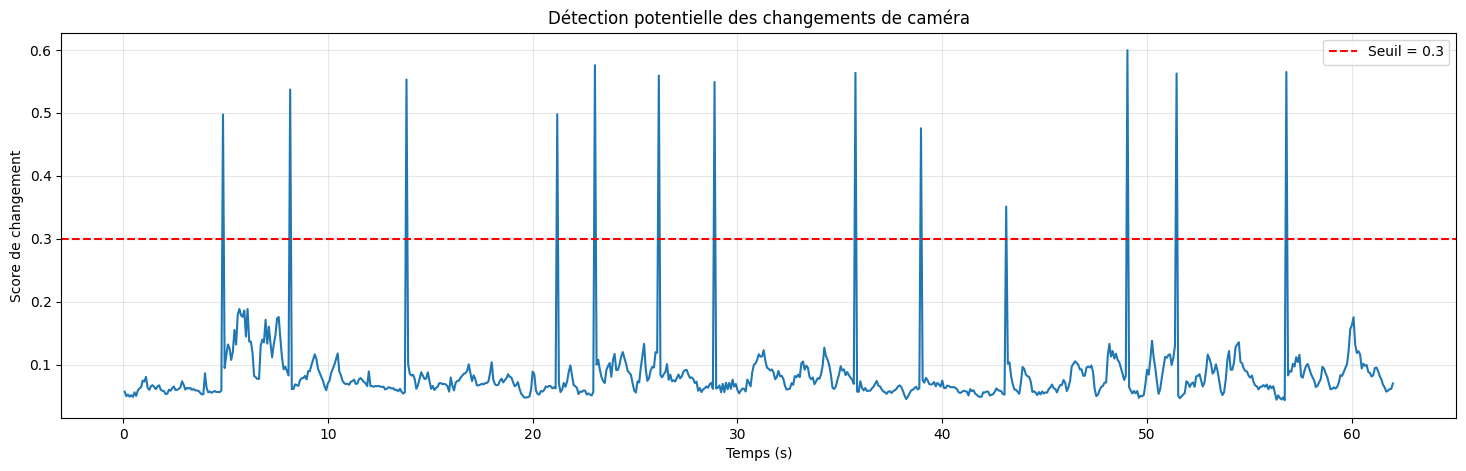

In [41]:
plt.figure(figsize=(18, 5))

plt.plot(
    camera_scores["time"],
    camera_scores["score"]
)

plt.axhline(
    CAMERA_CUT_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Seuil = {CAMERA_CUT_THRESHOLD}"
)

plt.xlabel("Temps (s)")
plt.ylabel("Score de changement")
plt.title("Détection potentielle des changements de caméra")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


In [43]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(
    model_asset_path=str(POSE_MODEL)
)

pose_options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

pose_landmarker = (
    vision.PoseLandmarker
    .create_from_options(pose_options)
)

print("Nouveau Pose Landmarker créé.")

Nouveau Pose Landmarker créé.


In [44]:
# ============================================================
# ANALYSE VIDÉO AVEC DÉTECTION DES CHANGEMENTS DE CAMÉRA
# ============================================================

CAMERA_CUT_THRESHOLD = 0.20

rows = []

cap = cv2.VideoCapture(str(VIDEO_PATH))

frame_idx = 0
processed = 0

previous_frame = None
camera_segment = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # --------------------------------------------------------
    # Échantillonnage
    # --------------------------------------------------------

    if frame_idx % FRAME_STEP != 0:

        frame_idx += 1
        continue

    timestamp = frame_idx / FPS
    
    # --------------------------------------------------------
    # Détection changement de caméra
    # --------------------------------------------------------

    camera_cut = False
    camera_change_score = np.nan

    if previous_frame is not None:

        camera_change_score = (
            calculate_camera_change_score(
                previous_frame,
                frame
            )
        )

        if camera_change_score > CAMERA_CUT_THRESHOLD:

            camera_segment += 1
            camera_cut = True

            print(
                f"\n"
                f"CHANGEMENT CAMÉRA détecté "
                f"à {timestamp:.2f} s | "
                f"score = {camera_change_score:.3f} | "
                f"segment = {camera_segment}"
            )

    previous_frame = frame.copy()


    # --------------------------------------------------------
    # MediaPipe
    # --------------------------------------------------------

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    pose_result = (
        pose_landmarker
        .detect_for_video(
            mp_image,
            int(timestamp * 1000)
        )
    )

    # --------------------------------------------------------
    # YOLO
    # --------------------------------------------------------

    yolo_result = yolo_model.predict(
        source=frame,
        conf=0.25,
        verbose=False
    )[0]

    bicycle = get_bicycle_detection(
        yolo_result
    )

    # --------------------------------------------------------
    # Valeurs par défaut
    # --------------------------------------------------------

    data = {

        "frame": frame_idx,
        "time": timestamp,

        "camera_segment": camera_segment,
        "camera_cut": camera_cut,
        "camera_change_score": camera_change_score,

        "body_x": np.nan,
        "body_y": np.nan,

        "head_x": np.nan,
        "head_y": np.nan,

        "left_hand_x": np.nan,
        "left_hand_y": np.nan,

        "right_hand_x": np.nan,
        "right_hand_y": np.nan,

        "left_foot_x": np.nan,
        "left_foot_y": np.nan,

        "right_foot_x": np.nan,
        "right_foot_y": np.nan,

        "bike_x": np.nan,
        "bike_y": np.nan,

        "bike_width": np.nan,
        "bike_height": np.nan,

        "bike_confidence": np.nan
    }

    # --------------------------------------------------------
    # Pose
    # --------------------------------------------------------

    if pose_result.pose_landmarks:

        lm = pose_result.pose_landmarks[0]

        def xy(index):

            return (
                lm[index].x,
                lm[index].y
            )

        head = xy(0)

        left_shoulder = xy(11)
        right_shoulder = xy(12)

        left_hip = xy(23)
        right_hip = xy(24)

        left_hand = xy(15)
        right_hand = xy(16)

        left_foot = xy(31)
        right_foot = xy(32)

        shoulder_x = (
            left_shoulder[0]
            + right_shoulder[0]
        ) / 2

        shoulder_y = (
            left_shoulder[1]
            + right_shoulder[1]
        ) / 2

        hip_x = (
            left_hip[0]
            + right_hip[0]
        ) / 2

        hip_y = (
            left_hip[1]
            + right_hip[1]
        ) / 2

        body_x = (
            shoulder_x + hip_x
        ) / 2

        body_y = (
            shoulder_y + hip_y
        ) / 2

        data.update({

            "body_x": body_x,
            "body_y": body_y,

            "head_x": head[0],
            "head_y": head[1],

            "left_hand_x": left_hand[0],
            "left_hand_y": left_hand[1],

            "right_hand_x": right_hand[0],
            "right_hand_y": right_hand[1],

            "left_foot_x": left_foot[0],
            "left_foot_y": left_foot[1],

            "right_foot_x": right_foot[0],
            "right_foot_y": right_foot[1]
        })

    # --------------------------------------------------------
    # Vélo
    # --------------------------------------------------------

    if bicycle is not None:

        x1 = bicycle["x1"]
        y1 = bicycle["y1"]
        x2 = bicycle["x2"]
        y2 = bicycle["y2"]

        data.update({

            "bike_x": (x1 + x2) / 2 / WIDTH,
            "bike_y": (y1 + y2) / 2 / HEIGHT,

            "bike_width":
                (x2 - x1) / WIDTH,

            "bike_height":
                (y2 - y1) / HEIGHT,

            "bike_confidence":
                bicycle["confidence"]
        })

    rows.append(data)

    processed += 1

    if processed % 20 == 0:

        print(
            f"\rAnalyse : "
            f"{timestamp:.1f} / "
            f"{DURATION:.1f} s",
            end=""
        )

    frame_idx += 1


cap.release()

print("\nAnalyse terminée.")


Analyse : 4.7 / 62.1 s
CHANGEMENT CAMÉRA détecté à 4.88 s | score = 0.497 | segment = 1
Analyse : 7.9 / 62.1 s
CHANGEMENT CAMÉRA détecté à 8.16 s | score = 0.537 | segment = 2
Analyse : 12.7 / 62.1 s
CHANGEMENT CAMÉRA détecté à 13.84 s | score = 0.553 | segment = 3
Analyse : 20.7 / 62.1 s
CHANGEMENT CAMÉRA détecté à 21.20 s | score = 0.498 | segment = 4
Analyse : 22.3 / 62.1 s
CHANGEMENT CAMÉRA détecté à 23.04 s | score = 0.576 | segment = 5
Analyse : 25.5 / 62.1 s
CHANGEMENT CAMÉRA détecté à 26.16 s | score = 0.559 | segment = 6
Analyse : 28.7 / 62.1 s
CHANGEMENT CAMÉRA détecté à 28.88 s | score = 0.549 | segment = 7
Analyse : 35.1 / 62.1 s
CHANGEMENT CAMÉRA détecté à 35.76 s | score = 0.564 | segment = 8
Analyse : 38.3 / 62.1 s
CHANGEMENT CAMÉRA détecté à 38.96 s | score = 0.476 | segment = 9
Analyse : 41.5 / 62.1 s
CHANGEMENT CAMÉRA détecté à 43.12 s | score = 0.351 | segment = 10
Analyse : 47.9 / 62.1 s
CHANGEMENT CAMÉRA détecté à 49.04 s | score = 0.600 | segment = 11
Analyse : 51

In [45]:
df = pd.DataFrame(rows)

CSV_PATH = (
    OUTPUT_DIR /
    "motion_data.csv"
)

df.to_csv(
    CSV_PATH,
    index=False
)

print("Données sauvegardées :")
print(CSV_PATH)


Données sauvegardées :
C:\Users\USER\Downloads\BMX_FreeF_diehm_run1_analysis\motion_data.csv


In [46]:
print(df.shape)
display(df.head())
display(df.tail())


(776, 22)


,frame,time,camera_segment,camera_cut,camera_change_score,body_x,body_y,head_x,head_y,left_hand_x,...,right_hand_y,left_foot_x,left_foot_y,right_foot_x,right_foot_y,bike_x,bike_y,bike_width,bike_height,bike_confidence
0,0,0.00,0,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0.08,0,False,0.056835,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,0.16,0,False,0.049615,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6,0.24,0,False,0.052380,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8,0.32,0,False,0.048959,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,frame,time,camera_segment,camera_cut,camera_change_score,body_x,body_y,head_x,head_y,left_hand_x,...,right_hand_y,left_foot_x,left_foot_y,right_foot_x,right_foot_y,bike_x,bike_y,bike_width,bike_height,bike_confidence
771,1542,61.68,13,False,0.056931,0.466623,0.364986,0.516774,0.312128,0.470060,...,0.377201,0.352645,0.474960,0.353565,0.492295,NaN,NaN,NaN,NaN,NaN
772,1544,61.76,13,False,0.058494,0.468035,0.358578,0.526967,0.334481,0.470921,...,0.397590,0.366836,0.467883,0.366378,0.495649,NaN,NaN,NaN,NaN,NaN
773,1546,61.84,13,False,0.060816,0.476207,0.349005,0.540017,0.342393,0.479881,...,0.401104,0.384453,0.481166,0.386669,0.497872,NaN,NaN,NaN,NaN,NaN
774,1548,61.92,13,False,0.061327,0.491754,0.342720,0.557286,0.339094,0.496481,...,0.421229,0.406966,0.476016,0.407597,0.509818,NaN,NaN,NaN,NaN,NaN
775,1550,62.00,13,False,0.069923,0.508737,0.343120,0.575568,0.338982,0.518547,...,0.426586,0.426559,0.463672,0.428763,0.520987,NaN,NaN,NaN,NaN,NaN


In [48]:
print(
    "Frames analysées :", len(df)
)

print(
    "Vélo détecté :",
    df["bike_confidence"].notna().sum()
)

print(
    "Pourcentage :",
    f"{100 * df['bike_confidence'].notna().mean():.1f}%"
)


Frames analysées : 776
Vélo détecté : 335
Pourcentage : 43.2%


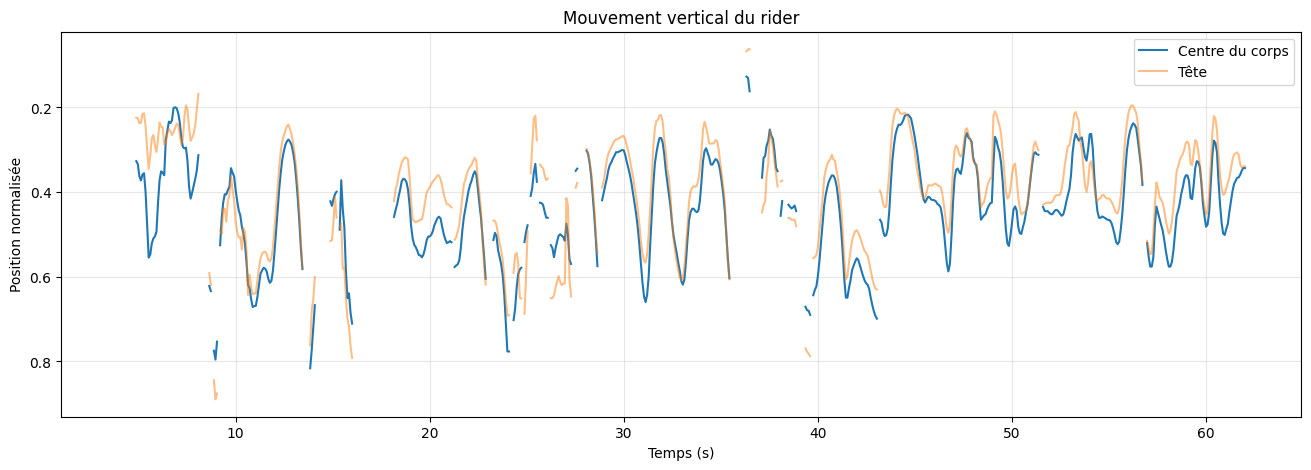

In [49]:
plt.figure(figsize=(16, 5))

plt.plot(
    df["time"],
    df["body_y"],
    label="Centre du corps"
)

plt.plot(
    df["time"],
    df["head_y"],
    alpha=0.5,
    label="Tête"
)

plt.gca().invert_yaxis()

plt.xlabel("Temps (s)")
plt.ylabel("Position normalisée")
plt.title("Mouvement vertical du rider")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


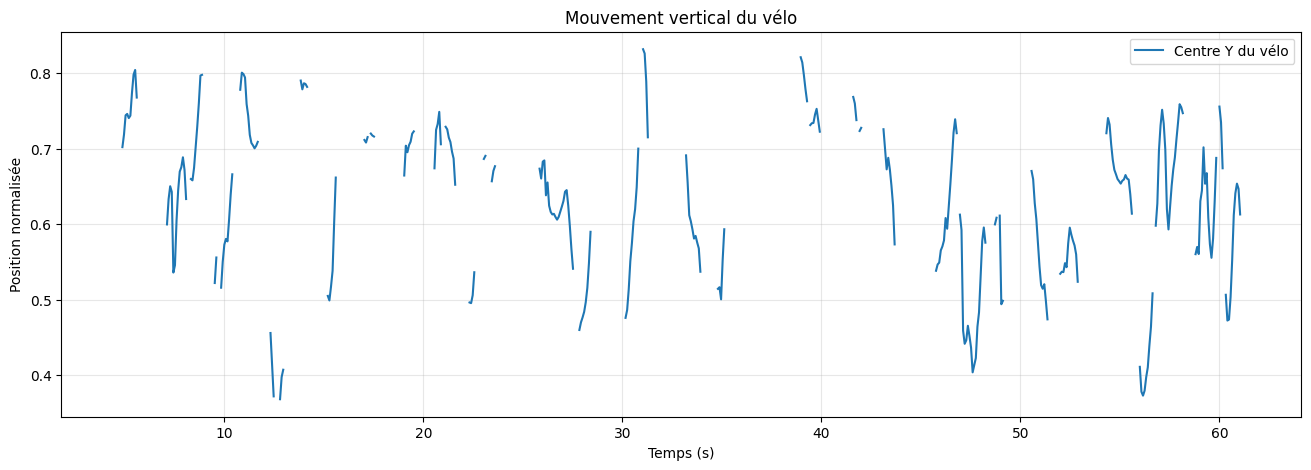

In [50]:
plt.figure(figsize=(16, 5))

plt.plot(
    df["time"],
    df["bike_y"],
    label="Centre Y du vélo"
)

plt.xlabel("Temps (s)")
plt.ylabel("Position normalisée")
plt.title("Mouvement vertical du vélo")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


In [51]:
print("Frames analysées :", len(df))

print(
    "Rider détecté :",
    df["body_x"].notna().sum()
)

print(
    "Rider détecté (%):",
    f"{100 * df['body_x'].notna().mean():.1f}%"
)


Frames analysées : 776
Rider détecté : 619
Rider détecté (%): 79.8%


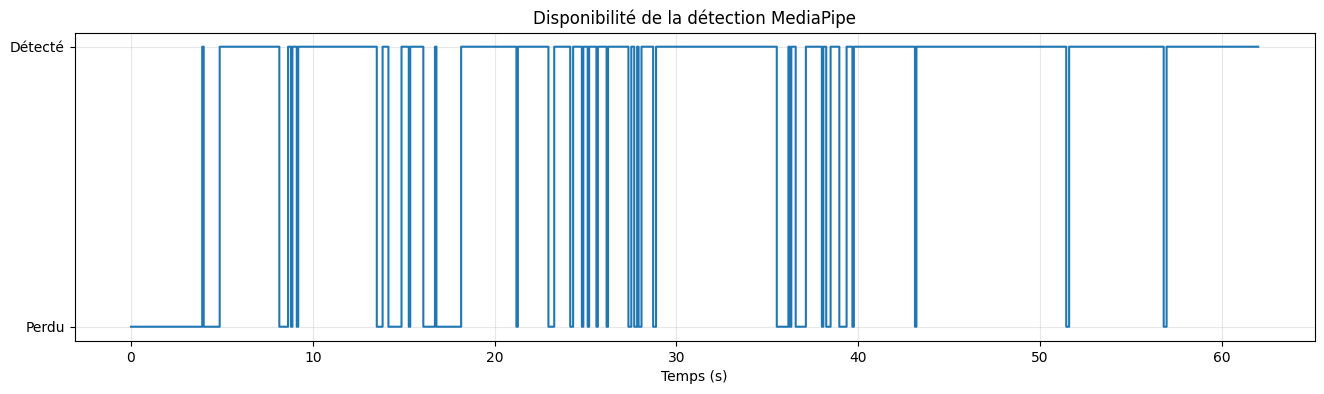

In [52]:
plt.figure(figsize=(16, 4))

plt.plot(
    df["time"],
    df["body_x"].notna().astype(int),
    drawstyle="steps-post"
)

plt.yticks([0, 1], ["Perdu", "Détecté"])
plt.xlabel("Temps (s)")
plt.title("Disponibilité de la détection MediaPipe")

plt.grid(alpha=0.3)
plt.show()


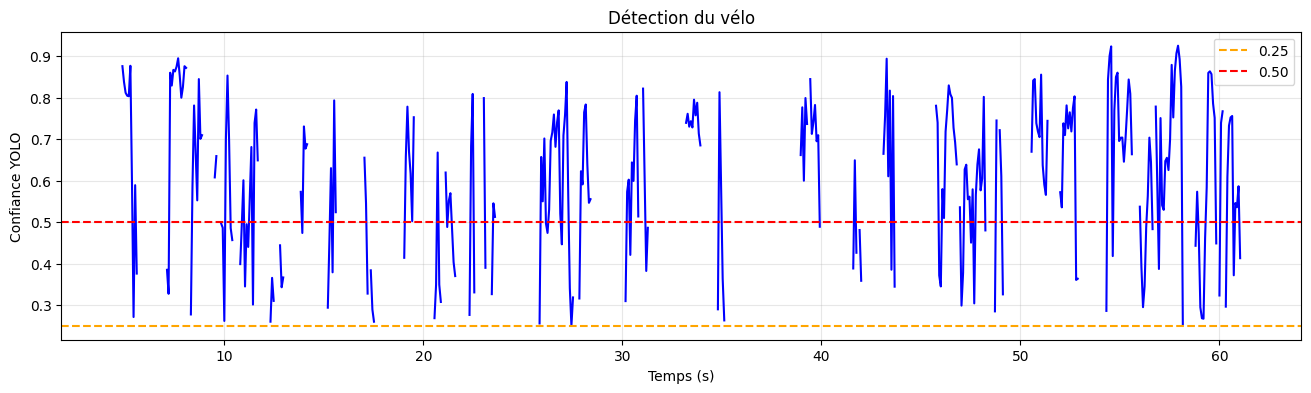

In [53]:
plt.figure(figsize=(16, 4))

plt.plot(
    df["time"],
    df["bike_confidence"],
    color="blue"
)

plt.axhline(
    0.25,
    color="orange",
    linestyle="--",
    label="0.25"
)

plt.axhline(
    0.50,
    color="red",
    linestyle="--",
    label="0.50"
)

plt.xlabel("Temps (s)")
plt.ylabel("Confiance YOLO")
plt.title("Détection du vélo")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


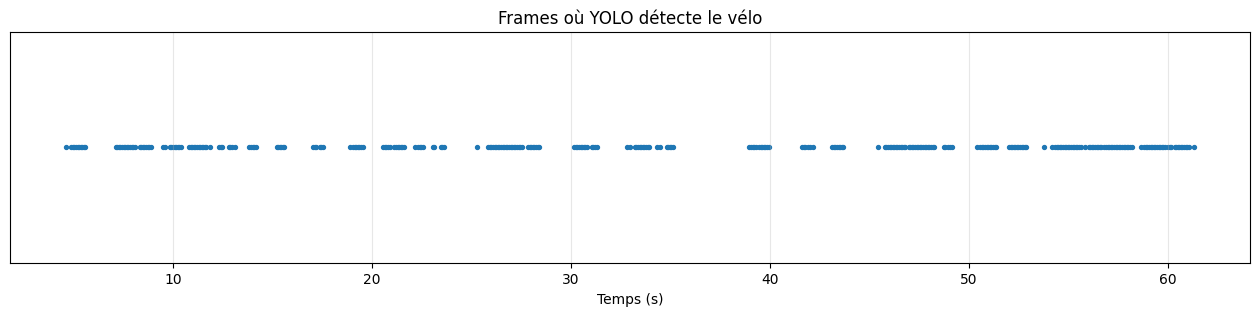

In [54]:
detected = df["bike_confidence"].notna()

plt.figure(figsize=(16, 3))

plt.scatter(
    df.loc[detected, "time"],
    np.ones(detected.sum()),
    s=8
)

plt.yticks([])
plt.xlabel("Temps (s)")
plt.title("Frames où YOLO détecte le vélo")

plt.grid(alpha=0.3)
plt.show()


In [55]:
from scipy.signal import find_peaks

# On travaille uniquement sur les frames où le rider est détecté
motion = df.dropna(subset=["body_y"]).copy()

# Lissage
motion["body_y_smooth"] = (
    motion["body_y"]
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
)

# Pics et creux
peaks, _ = find_peaks(
    motion["body_y_smooth"],
    distance=10,
    prominence=0.015
)

valleys, _ = find_peaks(
    -motion["body_y_smooth"],
    distance=10,
    prominence=0.015
)

print("Pics :", len(peaks))
print("Creux :", len(valleys))


Pics : 27
Creux : 28


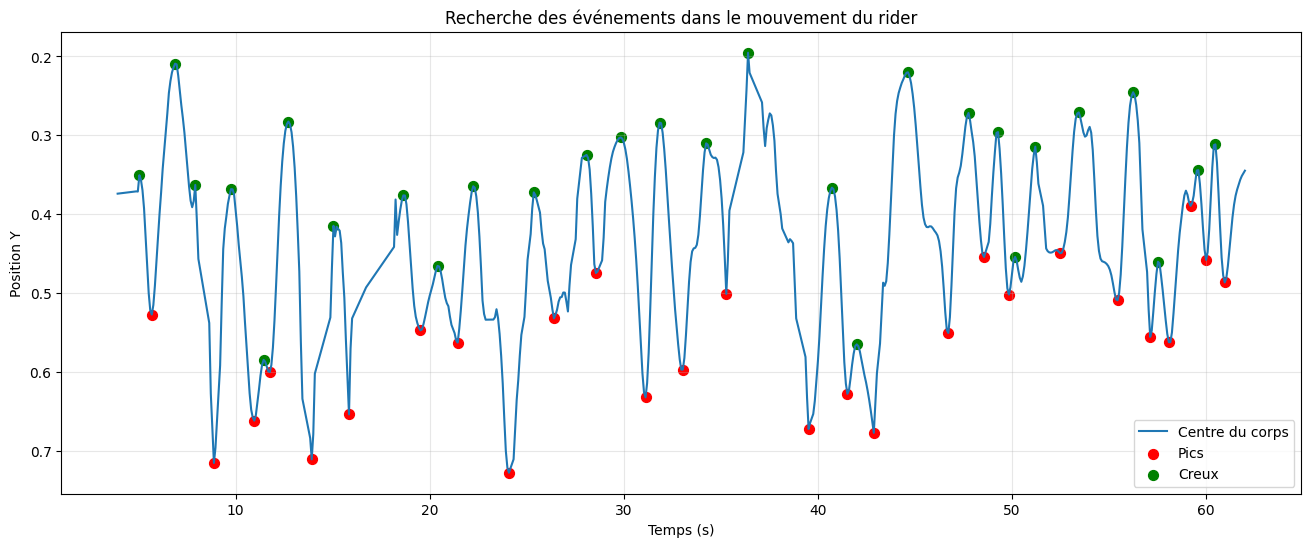

In [56]:
plt.figure(figsize=(16, 6))

plt.plot(
    motion["time"],
    motion["body_y_smooth"],
    label="Centre du corps"
)

plt.scatter(
    motion.iloc[peaks]["time"],
    motion.iloc[peaks]["body_y_smooth"],
    color="red",
    s=50,
    label="Pics"
)

plt.scatter(
    motion.iloc[valleys]["time"],
    motion.iloc[valleys]["body_y_smooth"],
    color="green",
    s=50,
    label="Creux"
)

plt.gca().invert_yaxis()

plt.xlabel("Temps (s)")
plt.ylabel("Position Y")
plt.title("Recherche des événements dans le mouvement du rider")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


In [57]:
import numpy as np

def angle_3points(a, b, c):
    """
    Angle ABC en degrés.
    """
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)

    ba = a - b
    bc = c - b

    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)

    if norm_ba == 0 or norm_bc == 0:
        return np.nan

    cos_angle = np.dot(ba, bc) / (
        norm_ba * norm_bc
    )

    cos_angle = np.clip(cos_angle, -1, 1)

    return np.degrees(
        np.arccos(cos_angle)
    )


In [58]:
df["hands_distance"] = np.sqrt(
    (
        df["left_hand_x"]
        - df["right_hand_x"]
    ) ** 2
    +
    (
        df["left_hand_y"]
        - df["right_hand_y"]
    ) ** 2
)

df["feet_distance"] = np.sqrt(
    (
        df["left_foot_x"]
        - df["right_foot_x"]
    ) ** 2
    +
    (
        df["left_foot_y"]
        - df["right_foot_y"]
    ) ** 2
)

df["body_head_distance"] = np.sqrt(
    (
        df["head_x"]
        - df["body_x"]
    ) ** 2
    +
    (
        df["head_y"]
        - df["body_y"]
    ) ** 2
)


In [59]:
# ============================================================
# VITESSES
# On ne calcule jamais une vitesse entre deux caméras
# ============================================================

df["dt"] = (
    df.groupby("camera_segment")["time"]
    .diff()
)

df["body_vx"] = (
    df.groupby("camera_segment")["body_x"]
    .diff()
    / df["dt"]
)

df["body_vy"] = (
    df.groupby("camera_segment")["body_y"]
    .diff()
    / df["dt"]
)

df["body_speed"] = np.sqrt(
    df["body_vx"] ** 2
    +
    df["body_vy"] ** 2
)


In [60]:
for col in [
    "body_y",
    "body_x",
    "body_vx",
    "body_vy",
    "body_speed",
    "hands_distance",
    "feet_distance"
]:

    df[f"{col}_smooth"] = (
        df[col]
        .rolling(
            window=5,
            center=True,
            min_periods=1
        )
        .mean()
    )


In [61]:
from scipy.signal import find_peaks

valid = df["body_y_smooth"].notna()

signal = df.loc[
    valid,
    "body_y_smooth"
].values

times = df.loc[
    valid,
    "time"
].values

peaks, peak_props = find_peaks(
    -signal,
    distance=10,
    prominence=0.02
)

jump_candidates = pd.DataFrame({

    "time": times[peaks],

    "body_y": signal[peaks],

    "prominence":
        peak_props["prominences"]
})

jump_candidates = jump_candidates.sort_values(
    "prominence",
    ascending=False
)

display(
    jump_candidates.head(20)
)


,time,body_y,prominence
6,16.72,0.168618,0.585682
17,36.40,0.139702,0.544884
4,12.72,0.282682,0.491765
21,44.64,0.220152,0.342376
14,29.84,0.302736,0.329725
15,31.84,0.283972,0.319341
1,6.88,0.209212,0.318211
19,40.72,0.366470,0.313446
27,56.24,0.245434,0.305347
5,15.12,0.413140,0.297382


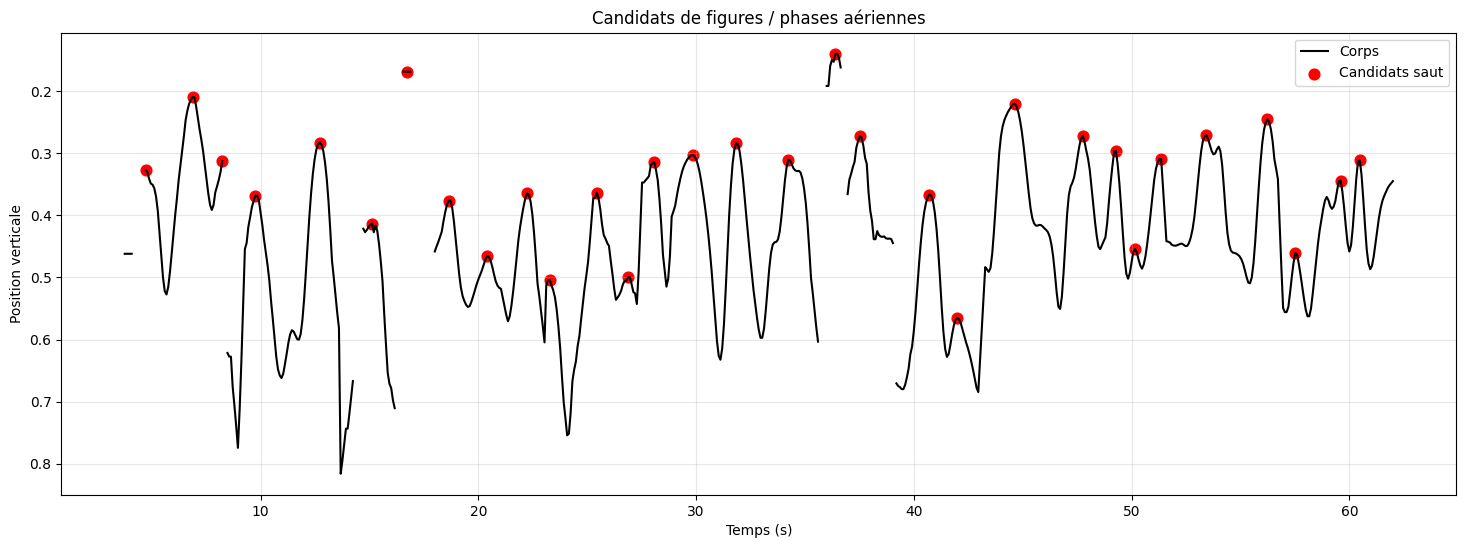

In [62]:
plt.figure(figsize=(18, 6))

plt.plot(
    df["time"],
    df["body_y_smooth"],
    color="black",
    label="Corps"
)

plt.scatter(
    jump_candidates["time"],
    jump_candidates["body_y"],
    color="red",
    s=60,
    label="Candidats saut"
)

plt.gca().invert_yaxis()

plt.xlabel("Temps (s)")
plt.ylabel("Position verticale")
plt.title(
    "Candidats de figures / phases aériennes"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()


In [63]:
EVENT_WINDOW = 1.5

events = []

for _, candidate in jump_candidates.head(30).iterrows():

    t = candidate["time"]

    window = df[
        (df["time"] >= t - EVENT_WINDOW)
        &
        (df["time"] <= t + EVENT_WINDOW)
    ].copy()

    if len(window) < 5:
        continue

    event = {
        "time": t,

        "vertical_amplitude":
            window["body_y"].max()
            - window["body_y"].min(),

        "hands_amplitude":
            window["hands_distance"].max()
            - window["hands_distance"].min(),

        "feet_amplitude":
            window["feet_distance"].max()
            - window["feet_distance"].min(),

        "horizontal_amplitude":
            window["body_x"].max()
            - window["body_x"].min(),

        "max_speed":
            window["body_speed"].max(),

        "bike_detection_rate":
            window["bike_confidence"].notna().mean(),

        "mean_bike_confidence":
            window["bike_confidence"].mean()
    }

    events.append(event)

events_df = pd.DataFrame(events)

display(
    events_df.sort_values(
        "vertical_amplitude",
        ascending=False
    ).head(20)
)


,time,vertical_amplitude,hands_amplitude,feet_amplitude,horizontal_amplitude,max_speed,bike_detection_rate,mean_bike_confidence
27,8.24,0.596006,0.253830,0.357347,0.338189,0.982735,0.621622,0.718608
0,16.72,0.541904,0.151973,0.110530,0.316171,1.472223,0.297297,0.477220
2,12.72,0.540350,0.095709,0.078960,0.494346,0.896516,0.513514,0.499986
1,36.40,0.476232,0.149876,0.253583,0.503321,0.825439,0.081081,0.404881
10,9.76,0.452144,0.254629,0.360200,0.188330,0.982735,0.648649,0.567291
9,15.12,0.444217,0.176768,0.136200,0.409813,1.472223,0.297297,0.565825
16,25.44,0.443191,0.237238,0.327678,0.378568,1.144965,0.405405,0.620205
22,23.28,0.425608,0.206236,0.121493,0.204740,1.144965,0.270270,0.492809
5,31.84,0.388121,0.071355,0.174353,0.308718,0.986031,0.378378,0.596267
4,29.84,0.359511,0.082624,0.187229,0.225535,0.795277,0.378378,0.576165


In [64]:
def classify_event(row):

    vertical = row["vertical_amplitude"]
    feet = row["feet_amplitude"]
    hands = row["hands_amplitude"]
    horizontal = row["horizontal_amplitude"]

    # Gros mouvement vertical
    if vertical > 0.20:

        # Gros déplacement horizontal du corps
        if horizontal > 0.15:
            return "Saut + déplacement"

        # Forte variation des jambes
        if feet > 0.20:
            return "Saut / figure jambes"

        return "Saut"

    # Mouvement horizontal important
    if horizontal > 0.15:
        return "Déplacement / rotation"

    return "Mouvement faible"


events_df["classification"] = (
    events_df.apply(
        classify_event,
        axis=1
    )
)

display(
    events_df[
        [
            "time",
            "vertical_amplitude",
            "feet_amplitude",
            "hands_amplitude",
            "horizontal_amplitude",
            "classification"
        ]
    ]
)


,time,vertical_amplitude,feet_amplitude,hands_amplitude,horizontal_amplitude,classification
0,16.72,0.541904,0.110530,0.151973,0.316171,Saut + déplacement
1,36.40,0.476232,0.253583,0.149876,0.503321,Saut + déplacement
2,12.72,0.540350,0.078960,0.095709,0.494346,Saut + déplacement
3,44.64,0.286798,0.059062,0.074404,0.189988,Saut + déplacement
4,29.84,0.359511,0.187229,0.082624,0.225535,Saut + déplacement
5,31.84,0.388121,0.174353,0.071355,0.308718,Saut + déplacement
6,6.88,0.355057,0.352237,0.617585,0.323712,Saut + déplacement
7,40.72,0.329689,0.049126,0.137583,0.110967,Saut
8,56.24,0.338615,0.061624,0.058282,0.169460,Saut + déplacement
9,15.12,0.444217,0.136200,0.176768,0.409813,Saut + déplacement


In [65]:
def get_frame_at_time(video_path, time_sec):
    
    cap = cv2.VideoCapture(str(video_path))

    cap.set(
        cv2.CAP_PROP_POS_MSEC,
        time_sec * 1000
    )

    ret, frame = cap.read()

    cap.release()

    if not ret:
        return None

    return cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )


In [66]:
events_to_check = (
    events_df
    .sort_values(
        "vertical_amplitude",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

print(
    f"{len(events_to_check)} événements à vérifier"
)


20 événements à vérifier


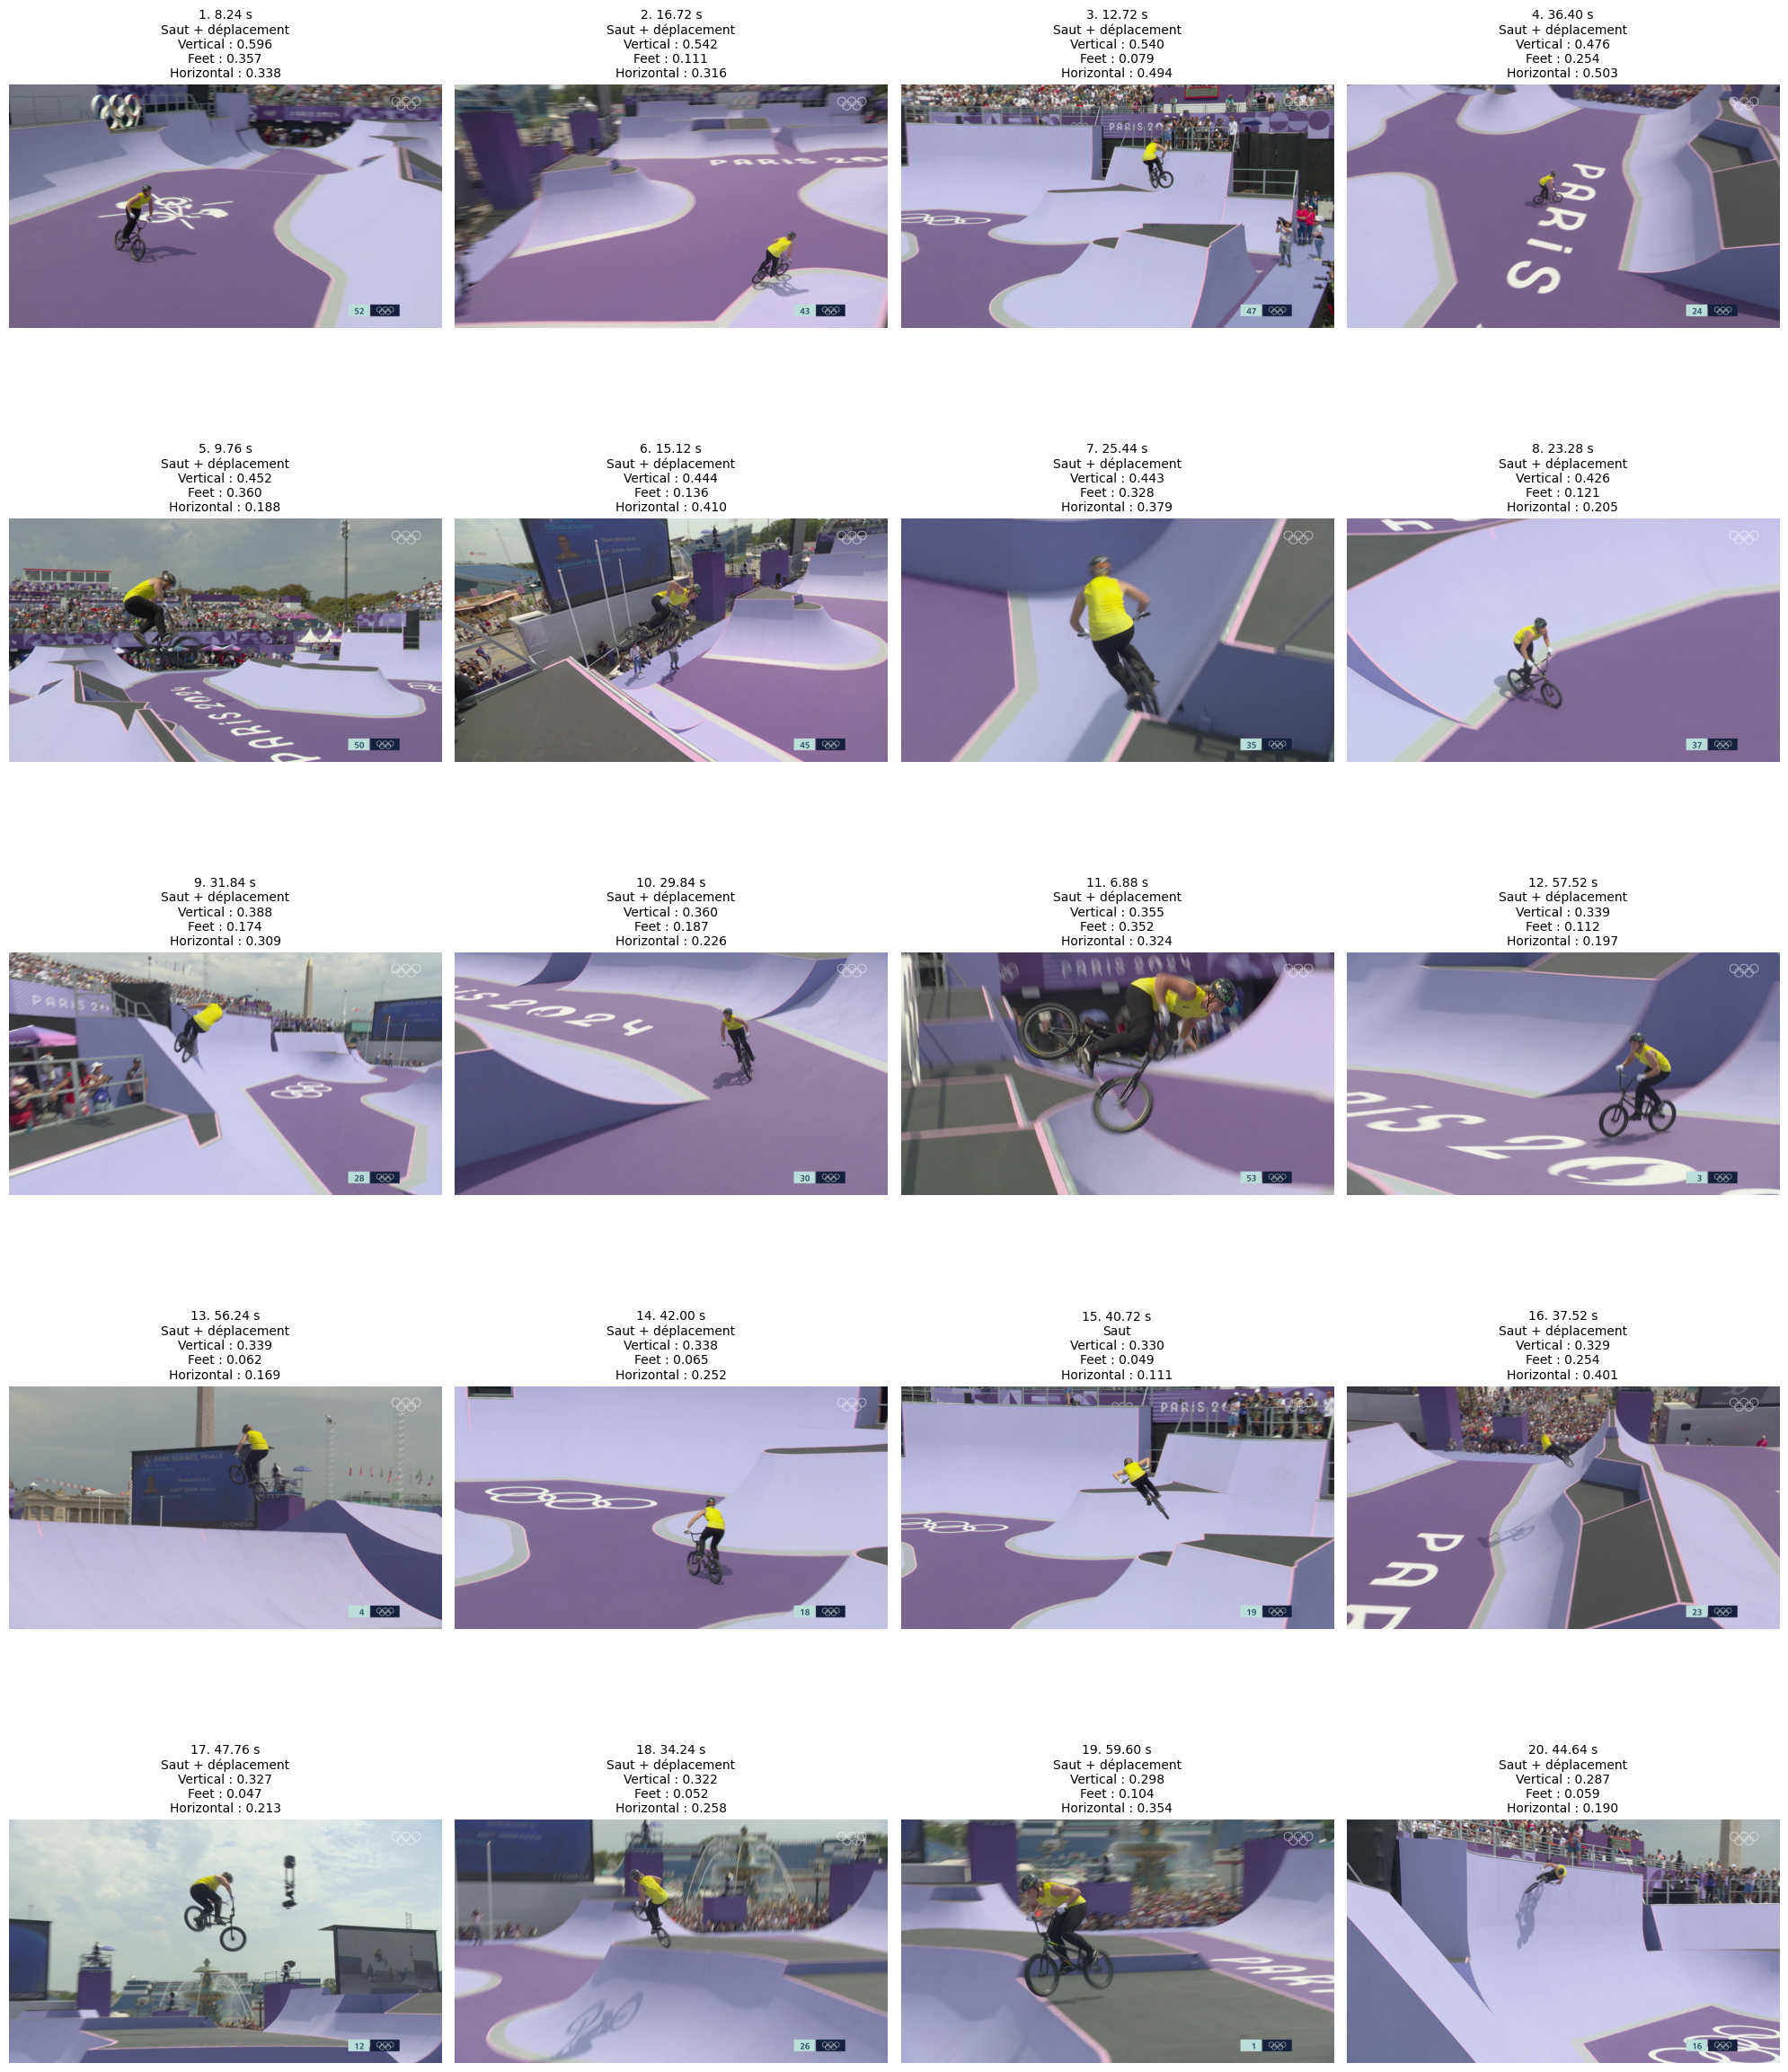

In [67]:
n = len(events_to_check)

cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(20, rows * 5)
)

axes = np.array(axes).reshape(-1)

for i, (_, event) in enumerate(
    events_to_check.iterrows()
):

    t = event["time"]

    frame_rgb = get_frame_at_time(
        VIDEO_PATH,
        t
    )

    ax = axes[i]

    if frame_rgb is not None:

        ax.imshow(frame_rgb)

    ax.axis("off")

    title = (
        f"{i+1}. {t:.2f} s\n"
        f"{event['classification']}\n"
        f"Vertical : {event['vertical_amplitude']:.3f}\n"
        f"Feet : {event['feet_amplitude']:.3f}\n"
        f"Horizontal : {event['horizontal_amplitude']:.3f}"
    )

    ax.set_title(
        title,
        fontsize=10
    )

# Cacher les cases inutilisées
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
